# 02 · Do histórico à próxima hora

**MACHINE LEARNING MEETS NETWORKS · ERRC 2026**  
Lorenzo Moreira Donatti · Deivis Felipe Guerreiro Fagundes

Nesta aula, vamos prever o RSSI de um enlace uma hora à frente, comparar com persistência e explicar quais informações podem ser usadas.

### Como acompanhar esta aula

Comece pela leitura dos dados e acompanhe as perguntas propostas em cada seção.
O código está pronto para executar; durante a aula, vamos discutir as escolhas e os resultados.
Use **Shift + Enter** para executar uma célula. No Colab, salve uma cópia no Drive.

**Distribuição dos 40 minutos:** ambiente (2) → cenário (3) → exploração (13) → lags (6) → split (4) → modelos (4) → avaliação (5) → discussão (3)

Este notebook é uma aula independente. CSVs pequenos são lidos do GitHub Raw; ambiente CPU padrão.
É necessário acesso à Internet. Não é preciso clonar o repositório nem montar o Drive.
O teste de ambiente foi incorporado ao passo 0: abra e execute as duas primeiras células antes do evento.

## 0 · Preparação do ambiente · 2 min

Execute as duas células. Este notebook não depende do anterior.
**Conferência:** **1.059 linhas e duas colunas**. Cada linha representa uma hora de um enlace fixo.
O CSV é baixado automaticamente do GitHub Raw; não precisamos coletar pacotes na aula.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
plt.rcParams.update({'figure.figsize': (9, 4), 'axes.grid': True, 'grid.alpha': 0.25})

In [2]:
# Dados públicos; versão fixada para reproduzir a aula.
import hashlib
import io
from urllib.request import urlopen

BASE_DADOS = 'https://raw.githubusercontent.com/LorenzoDonatti/ML_meets_networks_ERRC2026/e7b18b4133d3544ad4d6ed15e3599167031c54f7/data'

def carregar_csv(nome, sha256):
    with urlopen(f"{BASE_DADOS}/{nome}", timeout=30) as resposta:
        conteudo = resposta.read()
    assert hashlib.sha256(conteudo).hexdigest() == sha256, "Arquivo diferente da versão da aula."
    return pd.read_csv(io.BytesIO(conteudo))

df = carregar_csv('rssi_hourly.csv', 'daadf785ea27cc8b2ea34086c8bd84765bc4f4626eab4266d15ea5411e09e248')
print("Dados carregados:", df.shape)

Dados carregados: (1059, 2)


## 1 · O instante da previsão · 3 min

Imagine que você acompanha um sensor remoto. Ao terminar cada hora, chega um resumo
de RSSI. Você quer antecipar o valor da próxima hora para apoiar o monitoramento.

```text
               informações disponíveis               ainda desconhecido
─── hora t−2 ─── hora t−1 ─── hora t fechada ───┬─── hora t+1 ───→ tempo
                                              │
                                         emitir previsão
```

**Contrato:** depois de fechar a hora t, estimar a média de RSSI da hora t+1.
A média de t só pode ser utilizada quando sua janela estiver encerrada.

| Localização, aula anterior | Forecasting, agora |
|---|---|
| Vários gateways, um pacote | Um enlace, várias horas |
| Target: posição | Target: RSSI futuro |
| Erro em metros | Erro em dB |
| Separação por blocos | Passado treina, futuro testa |

A temperatura **observada amanhã** estaria disponível agora? E o horário de amanhã?

<details><summary>Comentário para discussão</summary>

A temperatura observada amanhã não existe agora. O horário de amanhã é conhecido. Uma previsão meteorológica emitida hoje seria outra informação, mas não faz parte desta prática.

</details>

## 2 · Explorando a série temporal · 13 min

A fonte contém 85 dias de uma rede com oito nós. Os tutores escolheram previamente o primeiro nó
e seu maior trecho sem lacunas. Isso evita que “linha anterior” signifique uma hora diferente.
Nenhum trecho foi escolhido pelo desempenho dos modelos.

Veja a curva. Ela varia lentamente? Tem saltos? Se você repetisse o último valor,
acertaria aproximadamente muitas horas?

> **Convenção:** timestamp identifica o balde horário; só disponibilizamos o agregado
> após seu fechamento. Este arquivo retrospectivo não comprova latência de ingestão real.

### 2.1 · Confirme o relógio e reserve o teste

Para explorar padrões, usaremos apenas o período de treinamento. O corte leva em conta as
24 horas iniciais necessárias aos lags, preservando exatamente a divisão usada mais adiante.
Um intervalo de medição irregular alteraria o significado de `shift(1)`.

In [3]:
df['timestamp'] = pd.to_datetime(df.timestamp, utc=True)
serie = df.set_index('timestamp').rssi_dbm.sort_index()
assert serie.index.to_series().diff().dropna().eq(pd.Timedelta(hours=1)).all()
assert serie.notna().all()
inicio_teste = serie.index[24 + int((len(serie) - 24) * 0.8)]
historico = serie.loc[serie.index < inicio_teste]
display(pd.DataFrame({'valor': [len(serie), len(historico), serie.isna().sum()]},
                     index=['Horas no recorte', 'Horas disponíveis para explorar', 'Valores ausentes']))
print('Teste reservado a partir de:', inicio_teste)

,valor
Horas no recorte,1059
Horas disponíveis para explorar,852
Valores ausentes,0


Teste reservado a partir de: 2021-01-04 22:00:00+00:00


### 2.2 · Observe em duas escalas

A série completa de treino revela mudanças de nível e episódios incomuns. Uma semana permite
enxergar a variação entre horas. Nenhum dos painéis abaixo usa o período reservado para teste.

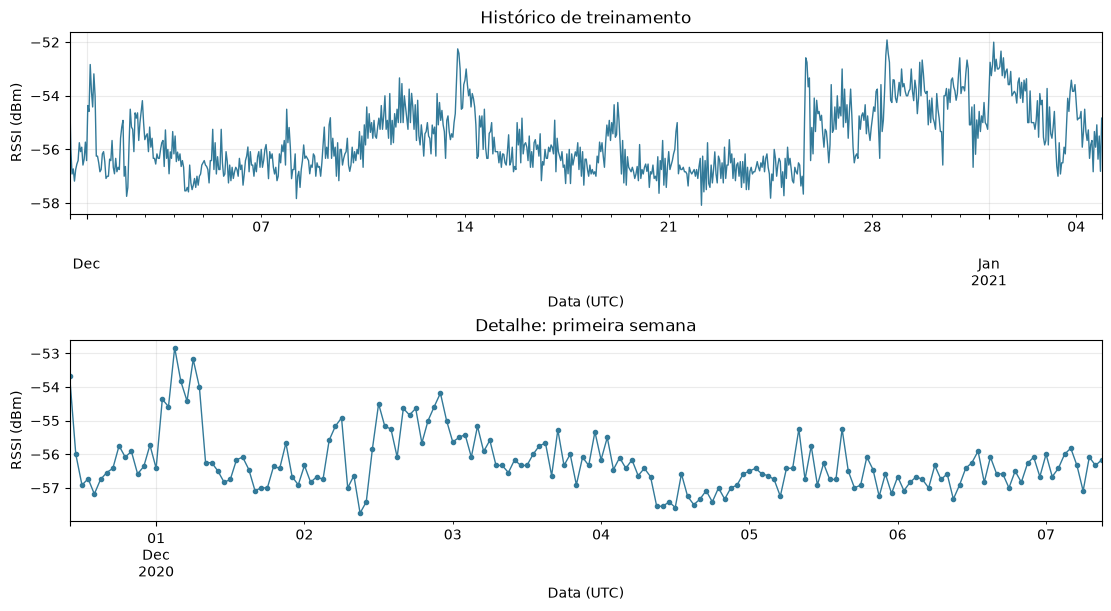

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(11, 6), constrained_layout=True)
historico.plot(ax=axes[0], color='#337a99', linewidth=1)
historico.iloc[:168].plot(ax=axes[1], color='#337a99', marker='.', linewidth=1)
axes[0].set(title='Histórico de treinamento', ylabel='RSSI (dBm)', xlabel='Data (UTC)')
axes[1].set(title='Detalhe: primeira semana', ylabel='RSSI (dBm)', xlabel='Data (UTC)')
plt.show()

**O que procurar:** trechos estáveis, saltos, valores isolados e mudanças de patamar.
A média horária já reduz parte da variação dos pacotes individuais; não estamos observando o
sinal instantâneo do rádio.

### 2.3 · Nível do sinal e tamanho das mudanças

O histograma da esquerda responde “quais potências aparecem?”. O da direita responde
“quanto a potência muda de uma hora para outra?”. Essa segunda pergunta já sugere como
avaliar a persistência: seu erro absoluto é o módulo dessa variação.

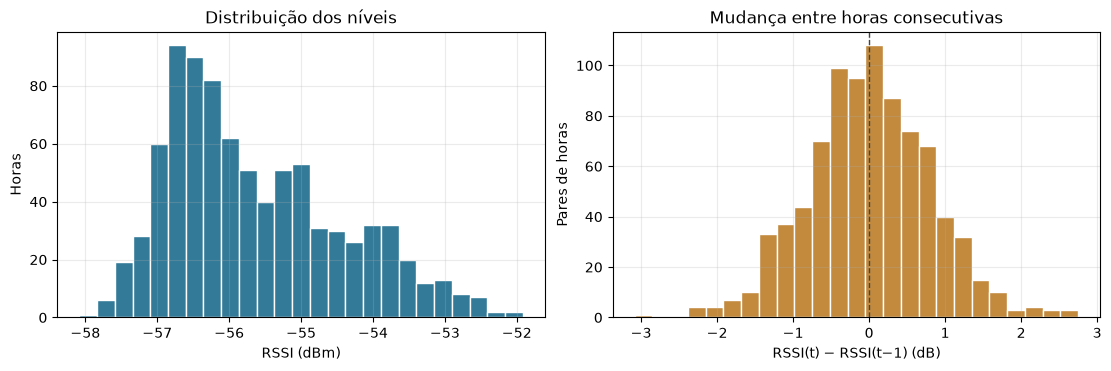

count    851.00
mean       0.64
std        0.50
min        0.00
50%        0.50
90%        1.33
max        3.08
Name: Variação absoluta (dB), dtype: float64

In [5]:
variacao = historico.diff().dropna()
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), constrained_layout=True)
axes[0].hist(historico, bins=25, color='#337a99', edgecolor='white')
axes[1].hist(variacao, bins=25, color='#c38a3d', edgecolor='white')
axes[1].axvline(0, color='#444444', linestyle='--', linewidth=1)
axes[0].set(title='Distribuição dos níveis', xlabel='RSSI (dBm)', ylabel='Horas')
axes[1].set(title='Mudança entre horas consecutivas', xlabel='RSSI(t) − RSSI(t−1) (dB)', ylabel='Pares de horas')
plt.show()
display(variacao.abs().describe(percentiles=[0.5, 0.9]).round(2).rename('Variação absoluta (dB)'))

### 2.4 · Quanto do presente se parece com o passado?

Cada ponto compara duas horas do treino. A diagonal indica igualdade: pontos próximos dela
favorecem repetir o valor passado. Compare 1, 6 e 24 horas, usando a mesma escala.
Não usaremos estes gráficos para procurar uma combinação vencedora de lags; a lista da aula
permanece fixada previamente.

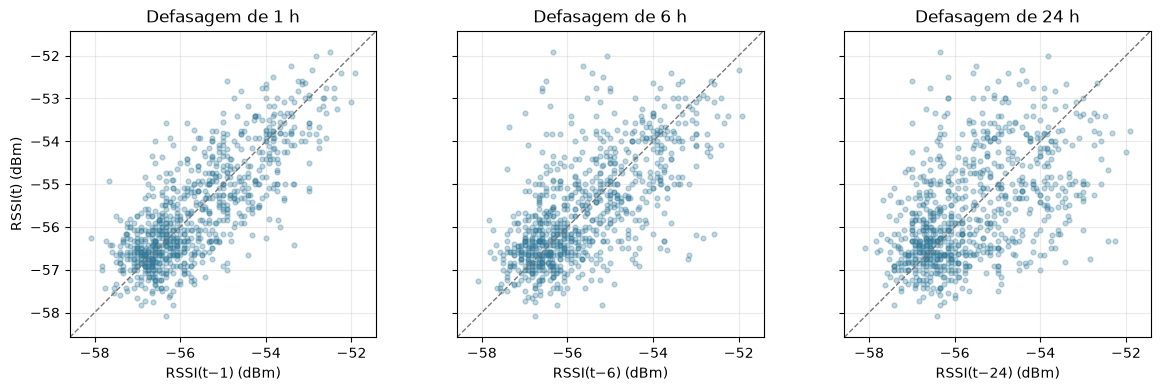

In [6]:
limites = [historico.min() - 0.5, historico.max() + 0.5]
fig, axes = plt.subplots(1, 3, figsize=(12, 3.8), sharex=True, sharey=True, constrained_layout=True)
for ax, k in zip(axes, [1, 6, 24]):
    ax.scatter(historico.shift(k), historico, s=12, alpha=0.3, color='#337a99')
    ax.plot(limites, limites, '--', color='#777777', linewidth=1)
    ax.set(title=f'Defasagem de {k} h', xlabel=f'RSSI(t−{k}) (dBm)', xlim=limites, ylim=limites, aspect='equal')
axes[0].set_ylabel('RSSI(t) (dBm)')
plt.show()

### Leitura complementar: autocorrelação

O gráfico seguinte resume a associação entre a série e versões defasadas. Correlação alta
não prova que um modelo terá bom desempenho no futuro. Tendências também podem produzi-la.
Um valor em 24 h, isoladamente, não demonstra sazonalidade diária.

Se o tempo estiver curto, consulte este painel depois da aula: a comparação visual anterior
já basta para entender por que o histórico pode conter informação.

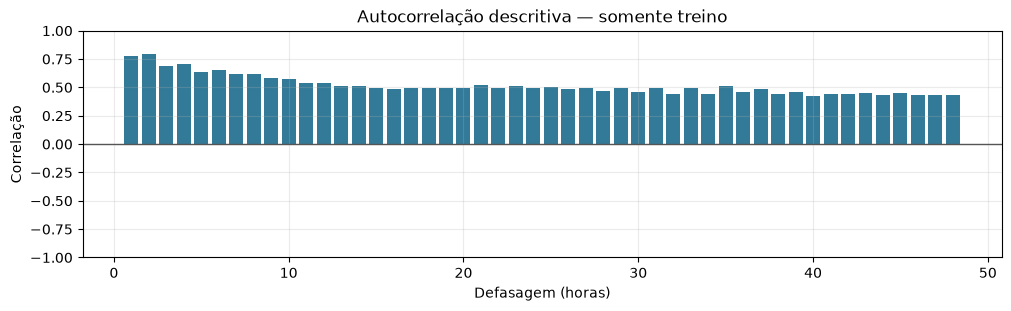

In [7]:
defasagens = np.arange(1, 49)
correlacoes = [historico.autocorr(lag=int(k)) for k in defasagens]
fig, ax = plt.subplots(figsize=(10, 3), constrained_layout=True)
ax.bar(defasagens, correlacoes, color='#337a99', width=0.8)
ax.axhline(0, color='#555555', linewidth=1)
ax.set(xlabel='Defasagem (horas)', ylabel='Correlação', title='Autocorrelação descritiva — somente treino', ylim=(-1, 1))
plt.show()

Agora temos uma justificativa para os próximos passos: representar valores passados como
atributos, manter a ordem do tempo e comparar qualquer modelo com a persistência.

## 3 · Do histórico à tabela de treinamento · 6 min

Uma tabela supervisionada precisa ligar **informação passada** a uma **resposta futura**.
Para evitar confusão de índices, cada linha abaixo recebe a hora-alvo **u = t+1**.

```text
y(u−24)   y(u−6)   y(u−3)   y(u−2)   y(u−1)  │  y(u)
   └────────────── entradas X ────────────────┘  │  target
                     já conhecidas             │  queremos prever
```

### Faça primeiro no papel

Exemplo fictício, somente para entender a montagem:

| Hora-alvo u | RSSI real y(u) | lag_1: y(u−1) | lag_2: y(u−2) |
|---|---:|---:|---:|
| 08 h | −80 | — | — |
| 09 h | −82 | −80 | — |
| 10 h | −81 | −82 | −80 |
| 11 h | ainda desconhecido | **−81** | **−82** |

Qual coluna será y? Qual valor a persistência preveria para 11 h?

`shift(1)` move uma observação para a linha seguinte: ela se torna passado para aquela linha.
`shift(-1)` colocaria o futuro como entrada. Usaremos lags **1, 2, 3, 6 e 24 horas**.

In [8]:
lags = [1, 2, 3, 6, 24]
tabela = pd.DataFrame({'target': serie})
for k in lags:
    tabela[f'lag_{k}'] = serie.shift(k)  # EXERCÍCIO: por que não shift(-k)?
display(tabela.head(4))
tabela = tabela.dropna()
features = [f'lag_{k}' for k in lags]
display(tabela.head(3))
print('Exemplos após histórico mínimo:', len(tabela))

,target,lag_1,lag_2,lag_3,lag_6,lag_24
timestamp,,,,,,
2020-11-30 10:00:00+00:00,-53.666667,NaN,NaN,NaN,NaN,NaN
2020-11-30 11:00:00+00:00,-56.000000,-53.666667,NaN,NaN,NaN,NaN
2020-11-30 12:00:00+00:00,-56.916667,-56.000000,-53.666667,NaN,NaN,NaN
2020-11-30 13:00:00+00:00,-56.727273,-56.916667,-56.000000,-53.666667,NaN,NaN


,target,lag_1,lag_2,lag_3,lag_6,lag_24
timestamp,,,,,,
2020-12-01 10:00:00+00:00,-56.500000,-56.250000,-56.25,-54.00,-53.833333,-53.666667
2020-12-01 11:00:00+00:00,-56.833333,-56.500000,-56.25,-56.25,-54.416667,-56.000000
2020-12-01 12:00:00+00:00,-56.750000,-56.833333,-56.50,-56.25,-53.181818,-56.916667


Exemplos após histórico mínimo: 1035


<details><summary>Comentário para discussão</summary>

O target é o RSSI real da hora-alvo. A persistência preveria −81 dBm às 11 h. As primeiras 24 linhas não têm todo o histórico: são descartadas, sem inventar valores. Restam 1.035 exemplos. O target permanece sem shift porque a tabela já está indexada pela hora que queremos prever.

</details>

## 4 · Divisão temporal · 4 min

```text
1.035 exemplos em ordem de hora-alvo
├──────────── 828 para treino ─────────────┼──── 207 para teste ────┤
aprender modelo e escala                   avaliar sem reajustar
```

Formar lags antes de cortar é seguro aqui: cada lag usa somente o passado.
Ajustar a média/desvio do scaler com toda a tabela não seria seguro.

**Como simulamos a operação:** prever uma hora, receber o valor real, atualizar o histórico,
prever a próxima. A observação anterior do teste já pode virar entrada quando chega.
O modelo permanece fixo. Não estamos prevendo todas as 207 horas de uma só vez.

Treino: 828 | teste: 207
Último alvo de treino: 2021-01-04 21:00:00+00:00
Primeiro alvo de teste: 2021-01-04 22:00:00+00:00


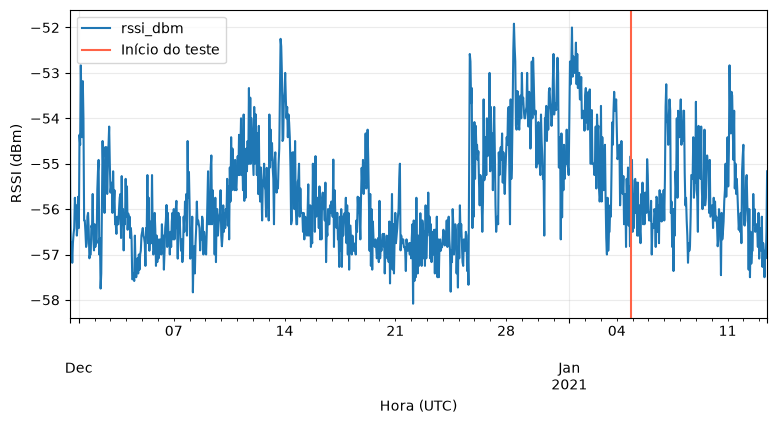

In [9]:
corte = int(len(tabela) * 0.8)
treino, teste = tabela.iloc[:corte], tabela.iloc[corte:]
assert treino.index.max() < teste.index.min()
print('Treino:', len(treino), '| teste:', len(teste))
print('Último alvo de treino:', treino.index.max())
print('Primeiro alvo de teste:', teste.index.min())
ax = serie.plot(ylabel='RSSI (dBm)', xlabel='Hora (UTC)')
ax.axvline(teste.index.min(), c='tomato', label='Início do teste'); ax.legend(); plt.show()

## 5 · Persistência e regressão Ridge · 4 min

**Persistência:** previsão para u = RSSI(u−1). É simples e pode ser difícil de superar.
**Ridge:** aprende a combinar os lags com pesos, limitando coeficientes excessivos.

```text
Treino → StandardScaler.fit → Ridge.fit
Teste  → mesma transformação → Ridge.predict
```

Leia a linha `modelo.fit(...)`: ela recebe o treino ou a tabela inteira?
Não precisamos otimizar hiperparâmetros para responder à pergunta didática.

In [10]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error
persistencia = teste.lag_1.to_numpy()
modelo = make_pipeline(StandardScaler(), Ridge(alpha=1.0))
modelo.fit(treino[features], treino.target)
previsto = modelo.predict(teste[features])

def metricas(real, pred):
    return {'MAE (dB)': mean_absolute_error(real, pred),
            'RMSE (dB)': np.sqrt(mean_squared_error(real, pred))}

resultados_ts = pd.DataFrame({
    'Persistência': metricas(teste.target, persistencia),
    'Ridge': metricas(teste.target, previsto)}).T
display(resultados_ts.round(3))

,MAE (dB),RMSE (dB)
Persistência,0.661,0.820
Ridge,0.535,0.695


## 6 · Avaliação das previsões · 5 min

| Medida | Como explicar a alguém de redes |
|---|---|
| RSSI observado | Potência em dBm |
| MAE | Tamanho médio do erro absoluto, em dB |
| RMSE | Erro em dB com maior peso para desvios grandes |

Exemplo: real −80 dBm, previsão −83 dBm → erro absoluto **3 dB**.

A tabela anterior usa **todo o teste**. O gráfico seguinte mostra somente as primeiras
**96 horas**, para legibilidade. Verifique se o modelo acompanha ou apenas atrasa os saltos.

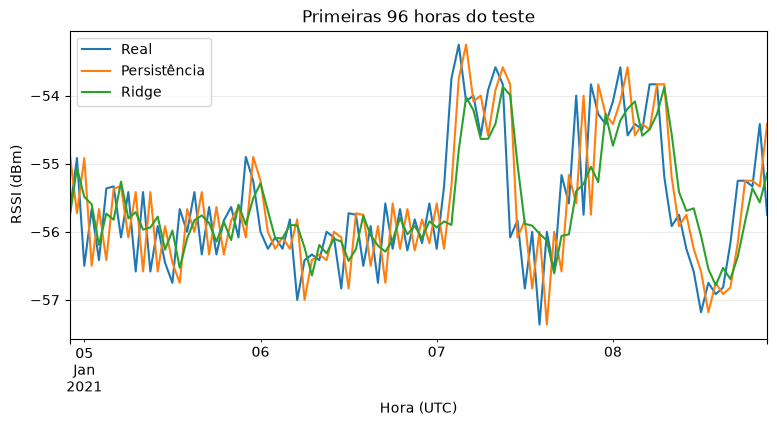

Redução do MAE frente à persistência: 19.1% (negativo = pior)


In [11]:
comparacao = pd.DataFrame({'Real': teste.target, 'Persistência': persistencia, 'Ridge': previsto})
comparacao.iloc[:96].plot(title='Primeiras 96 horas do teste', ylabel='RSSI (dBm)', xlabel='Hora (UTC)')
plt.show()
ganho = 100 * (1 - resultados_ts.loc['Ridge', 'MAE (dB)'] / resultados_ts.loc['Persistência', 'MAE (dB)'])
print(f'Redução do MAE frente à persistência: {ganho:.1f}% (negativo = pior)')

**Antes de aceitar o modelo:** o ganho é sobre qual baseline e em qual período?
Um MAE pequeno garante antecipar uma queda rara? Uma curva suave pode esconder esse problema.

<details><summary>Comentário para discussão</summary>

A referência local tem MAE de aproximadamente 0,661 dB para persistência e 0,535 dB para Ridge, redução de 19,1%. É um resultado do recorte e protocolo, não uma promessa. Para alertas, seria necessário avaliar eventos e custos específicos. RSSI sozinho não equivale a qualidade de serviço ou taxa de entrega.

</details>

## 7 · Aplicações e limites · 3 min

Complete e leia para seu colega:

> Quero prever ____ na hora ____. Antes da previsão, já conheço ____.
> Minha referência será ____. Vou testar no período ____ e medir erro em ____.

Pense em **latência**, **throughput** ou **tráfego**. O raciocínio continua, mas a unidade,
a disponibilidade e o custo de errar podem mudar.

### Quatro cartões para revisão oral

| Situação | Válida ou contaminada? |
|---|---|
| Usar a hora futura do calendário | ____ |
| Usar média móvel centralizada | ____ |
| Scaler treinado só no passado | ____ |
| Repetir testes para escolher os melhores lags | ____ |

<details><summary>Comentário para discussão</summary>

Calendário é válido; média centralizada usa futuro; scaler só no treino é correto; escolher lags pelo teste contamina a avaliação. Seleção de modelo exigiria validação separada dentro do passado.

</details>

### Revisão

- [ ] Sei explicar por que uma linha anterior precisa corresponder a uma hora anterior.
- [ ] Sei qual instante libera cada feature.
- [ ] Sei diferenciar previsão sequencial de um passo e previsão de vários passos sem observações.
- [ ] Comparei modelo e baseline no mesmo teste.
- [ ] Consigo relacionar o erro à decisão que a rede precisa tomar.

**Fonte e alterações:** [Goldoni et al., Computer Networks (2022)](https://doi.org/10.1016/j.comnet.2021.108627),
[repositório original](https://github.com/emanueleg/lora-rssi/tree/master/vineyard-2021_data), CC BY-SA 4.0.
Derivado: nó 01, maior trecho contínuo (1.059 horas), sem interpolação. Licença preservada.
**Para estudar depois:** [scikit-learn: pitfalls](https://scikit-learn.org/stable/common_pitfalls.html)
e [Forecasting: Principles and Practice](https://otexts.com/fpp3/).